# 03A — Sunspot pulsation analysis: DS01

Example notebook that applies the full pipeline from `src/sunspot_analysis.py` to the **DS01** region.

**Workflow**
1. Verify cadence from the `.sav` timing file
2. Load cubes + build umbra / penumbra masks (adjust thresholds if needed)
3. Calibration frame — visual check of the masks
4. Compute per-frame metrics
5. Save metrics CSV
6. Time-series plots
7. FFT plots (separate + combined with zoom)
8. Save animation

In [1]:
#%load_ext autoreload
#%autoreload 2

import sys
import pathlib

project_root = pathlib.Path.cwd()
if not (project_root / 'src').exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root.resolve()))

import numpy as np
import matplotlib.pyplot as plt

from src.sunspot_analysis import (
    verify_cadence,
    load_and_mask,
    plot_calibration_frame,
    compute_metrics,
    save_metrics_csv,
    plot_time_series,
    plot_ffts_separate,
    plot_ffts_combined,
    save_animation,
)

# DS01

In [2]:
# ── paths ─────────────────────────────────────────────────────────────────────
DS01_NAME      = 'DS01'
raw_dir_01      = pathlib.Path('../data/raw/sebastian_sun_spots') / DS01_NAME
processed_dir_01 = pathlib.Path('../data/processed/sebastian_sun_spots') / DS01_NAME
plots_dir_01    = processed_dir_01 / 'plots'

print('Raw data dir :', raw_dir_01)
print('Processed dir:', processed_dir_01)

NameError: name 'pathlib' is not defined

## Step 0 — Verify cadence from the `.sav` timing file

In [ ]:
cadence_s, cadence_list = verify_cadence(raw_dir_01)
arr, counts = np.unique(cadence_list, return_counts=True)
dict(zip(arr, counts))

(median 720.0 s, max dev 2160.00 s)


/home/thomas/Desktop/sun_spots_pulsation_review/src/sunspot_analysis.py:130: UserWarning: Cadence check failed: 21 gaps deviate from 720.0 s (max deviation 2160.0 s)
  warnings.warn(


{np.float64(720.0): np.int64(1045),
 np.float64(1440.0): np.int64(20),
 np.float64(2880.0): np.int64(1)}

## Step 1 — Load cubes and build region masks

Adjust `umbra_thresh` and `penumbra_thresh` after looking at the calibration frame below.
Run **Steps 1–2** together until the masks look right, then proceed.

In [ ]:
data = load_and_mask(
    ds_dir          = raw_dir_01,
    umbra_thresh    = 30_000,   # continuum DN — pixels below this → umbra
    penumbra_thresh = 50_000,   # continuum DN — upper bound for penumbra
    cadence_s       = cadence_list,
)

print(f"Cube shape (n_t, ny, nx): {data['cube_cont'].shape}")
print(f"Time span: {data['time_h'][-1]:.1f} h  ({data['n_t']} frames @ {data['cadence_s']:.0f} s)")

Cube shape (n_t, ny, nx): (1067, 239, 239)
Time span: 217.8 h  (1067 frames @ 720 s)


## Step 2 — Calibration frame

Change `frame_idx` to inspect any frame.  
Green overlay = umbra, purple = penumbra.

Figure saved → ../data/processed/sebastian_sun_spots/DS01/plots/calibration_frame_0000.png


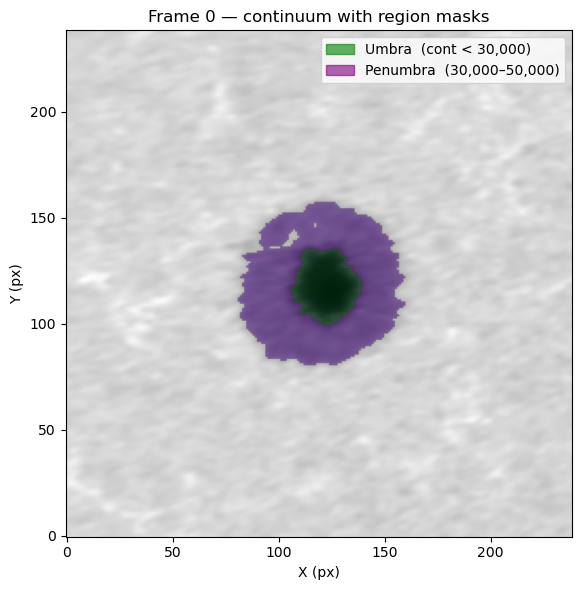

In [ ]:
plot_calibration_frame(
    data,
    frame_idx = 0,       # use None for the middle frame, or any integer
    save      = True,
    plots_dir = plots_dir_01,
)

Figure saved → ../data/processed/sebastian_sun_spots/DS01/plots/calibration_frame_0500.png


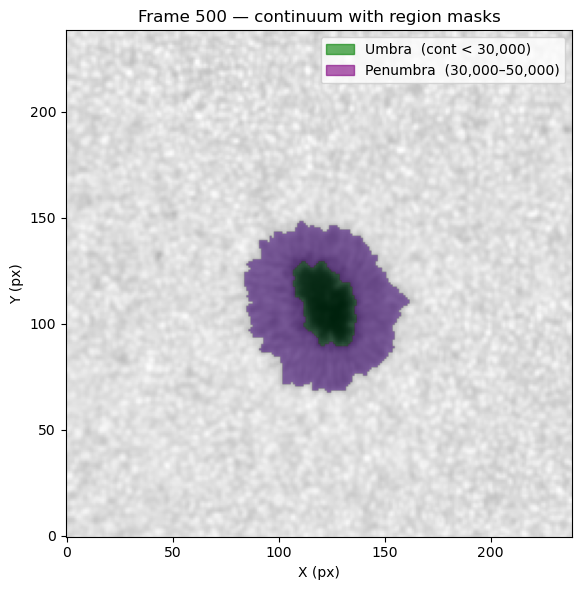

In [ ]:
# Intermediate frame check — useful when the sunspot evolves significantly
plot_calibration_frame(
    data,
    frame_idx = 500,
    save      = True,
    plots_dir = plots_dir_01,
)

## Step 3 — Compute per-frame metrics

In [7]:
metrics = compute_metrics(data)

n_pix = data['umbra'].sum(axis=(1, 2))
print(f"Umbra pixels/frame  →  mean={n_pix.mean():.0f}, min={n_pix.min()}, max={n_pix.max()}")
print(f"Mean B   umbra    : {np.nanmean(metrics['mean_mag_umb']):.1f} G")
print(f"Mean B   penumbra : {np.nanmean(metrics['mean_mag_pen']):.1f} G")
print(f"Mean v   umbra    : {np.nanmean(metrics['mean_dop_umb']):.1f} m/s")
print(f"Mean v   penumbra : {np.nanmean(metrics['mean_dop_pen']):.1f} m/s")

Umbra pixels/frame  →  mean=813, min=570, max=925
Mean B   umbra    : 1273.9 G
Mean B   penumbra : 361.3 G
Mean v   umbra    : -26.0 m/s
Mean v   penumbra : -146.1 m/s


## Step 4 — Save metrics CSV

In [ ]:
save_metrics_csv(data, metrics, processed_dir_01)

Metrics saved → ../data/processed/sebastian_sun_spots/DS01/metrics.csv  (1067 rows)


PosixPath('../data/processed/sebastian_sun_spots/DS01/metrics.csv')

## Step 5 — Time-series plots

Figure saved → ../data/processed/sebastian_sun_spots/DS01/plots/time_series.png


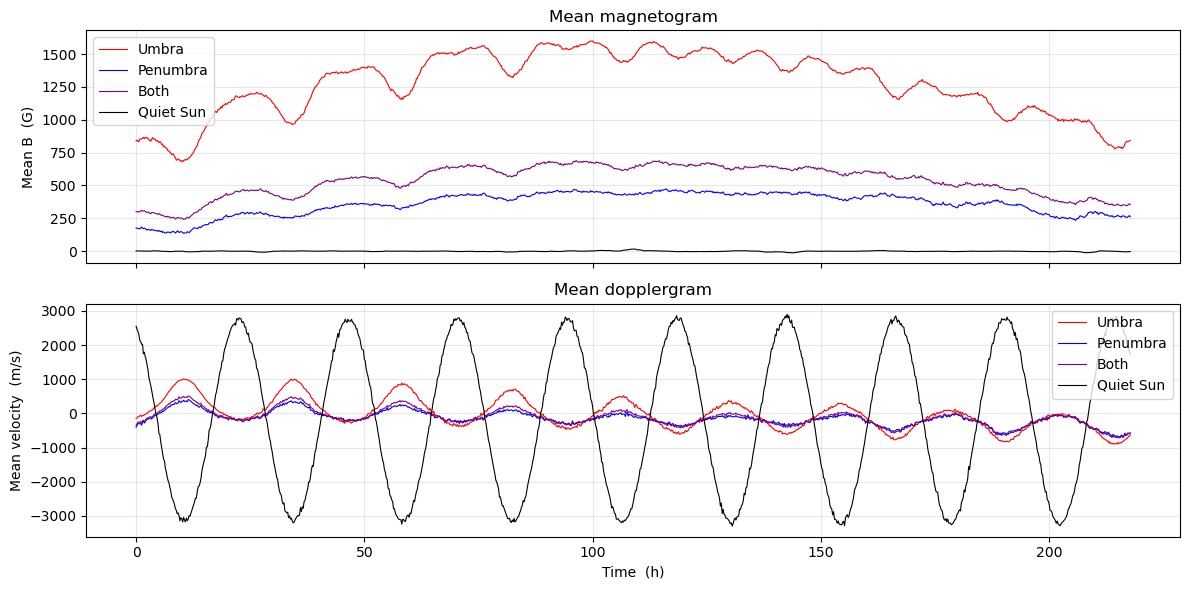

In [ ]:
plot_time_series(data, metrics, save=True, plots_dir=plots_dir_01)

Figure saved → ../data/processed/sebastian_sun_spots/DS01/plots/time_series_normalized.png


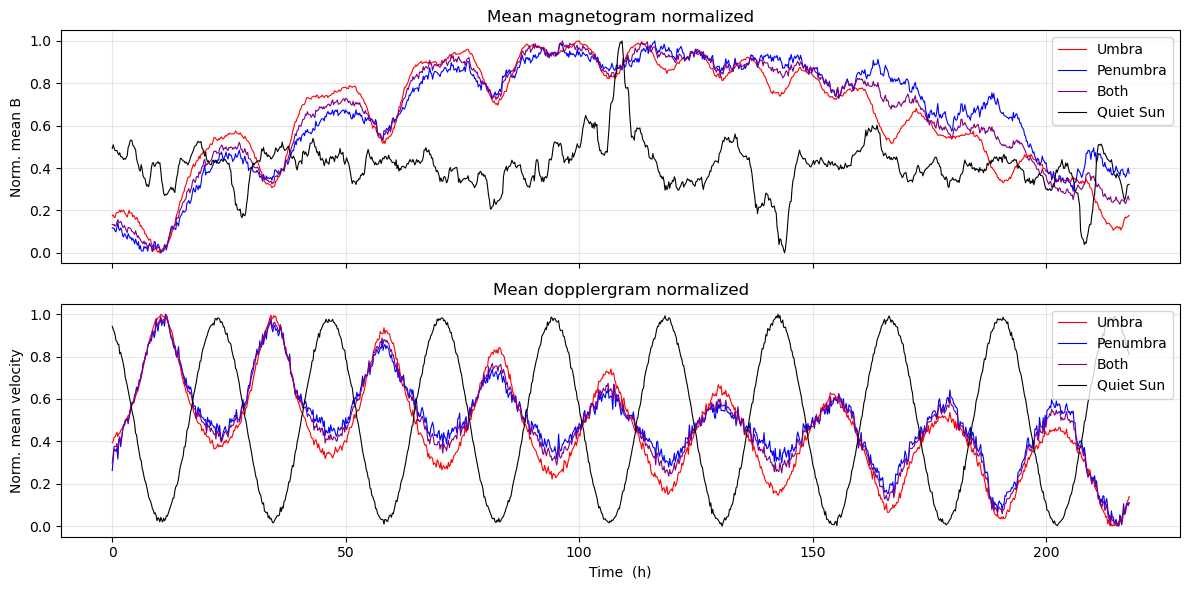

In [ ]:
plot_time_series(data, metrics, normalized=True, save=True, plots_dir=plots_dir_01)

## Step 6 — FFT analysis

### 6a — Separate subplots (one per region)

Figure saved → ../data/processed/sebastian_sun_spots/DS01/plots/fft_separate.png


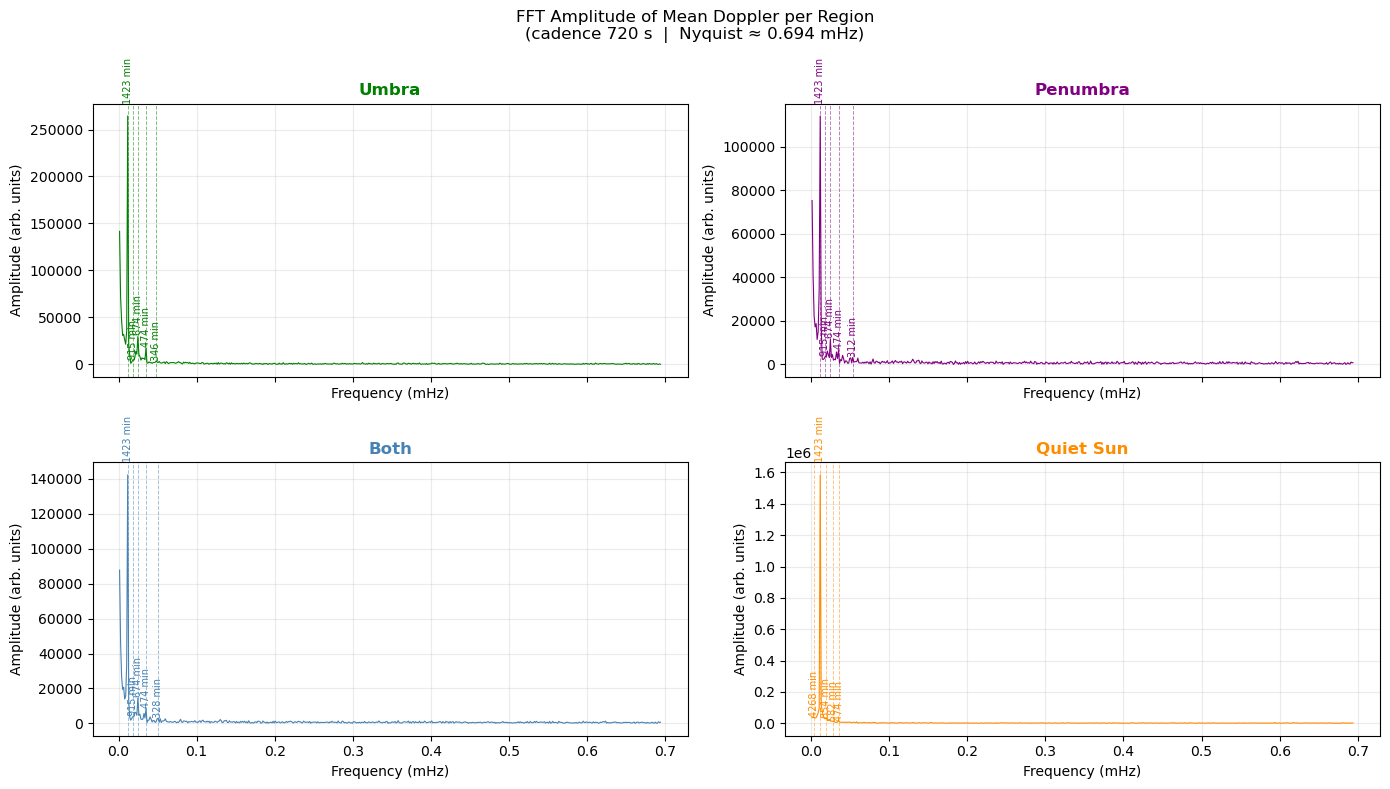


Region        Rank   Freq (mHz)   Period (min)  Rel. amplitude
────────────────────────────────────────────────────────────
Umbra            1       0.0117         1422.7          1.0000
Umbra            2       0.0247          673.9          0.1121
Umbra            3       0.0351          474.2          0.0674
Umbra            4       0.0182          914.6          0.0184
Umbra            5       0.0482          346.1          0.0141

Penumbra         1       0.0117         1422.7          1.0000
Penumbra         2       0.0247          673.9          0.1006
Penumbra         3       0.0351          474.2          0.0578
Penumbra         4       0.0182          914.6          0.0329
Penumbra         5       0.0534          312.3          0.0280

Both             1       0.0117         1422.7          1.0000
Both             2       0.0247          673.9          0.1021
Both             3       0.0351          474.2          0.0605
Both             4       0.0182          914.6        

In [ ]:
plot_ffts_separate(
    data, metrics,
    annotate_peaks = True,
    print_table    = True,
    save           = False,
    plots_dir      = plots_dir_01,
)

### 6b — Combined plot with x-axis zoom

Adjust `xlim` to focus on the frequency range of interest (in mHz).  
The peak-table CSV (`fft_peaks.csv`) is saved alongside the figure.

Figure saved → ../data/processed/sebastian_sun_spots/DS01/plots/fft_combined.png


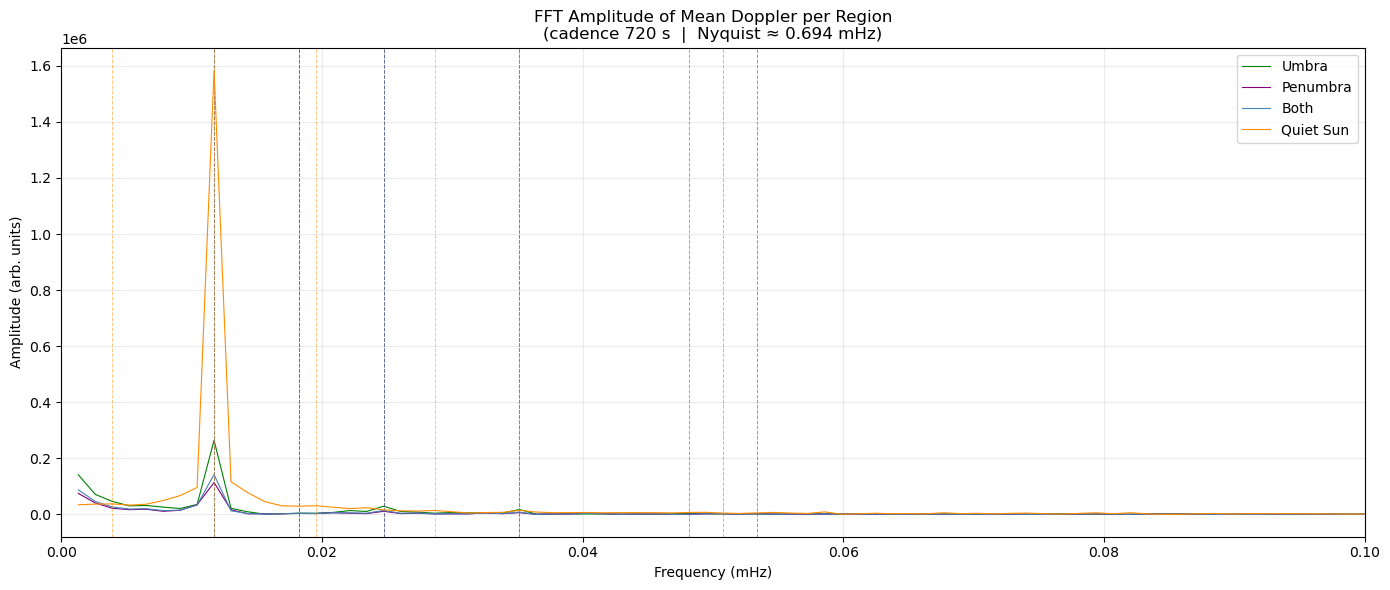


Region        Rank   Freq (mHz)   Period (min)  Rel. amplitude
────────────────────────────────────────────────────────────
Umbra            1       0.0117         1422.7          1.0000
Umbra            2       0.0247          673.9          0.1121
Umbra            3       0.0351          474.2          0.0674
Umbra            4       0.0182          914.6          0.0184
Umbra            5       0.0482          346.1          0.0141

Penumbra         1       0.0117         1422.7          1.0000
Penumbra         2       0.0247          673.9          0.1006
Penumbra         3       0.0351          474.2          0.0578
Penumbra         4       0.0182          914.6          0.0329
Penumbra         5       0.0534          312.3          0.0280

Both             1       0.0117         1422.7          1.0000
Both             2       0.0247          673.9          0.1021
Both             3       0.0351          474.2          0.0605
Both             4       0.0182          914.6        

In [ ]:
plot_ffts_combined(
    data, metrics,
    xlim           = (0, 0.1),   # mHz — change or set to None for full range
    annotate_peaks = True,
    print_table    = True,
    save           = True,
    plots_dir      = plots_dir_01,
)

## Step 7 — Save animation

In [ ]:
anim_path = processed_dir_01 / 'anim.html'

save_animation(
    data, metrics,
    save_path = anim_path,
    step      = 50,   # include every 50th frame
    fps       = 5,
)

Animation saved → ../data/processed/sebastian_sun_spots/DS01/anim.html


In [ ]:
# Open the saved animation in the browser
from IPython.display import FileLink
FileLink(str(anim_path))


/home/thomas/Desktop/sun_spots_pulsation_review/data/processed/sebastian_sun_spots/DS01/anim.html

# DS03

In [4]:
# ── paths ─────────────────────────────────────────────────────────────────────
DS03_NAME      = 'DS03'
raw_dir_03      = pathlib.Path('../data/raw/sebastian_sun_spots') / DS03_NAME
processed_dir_03 = pathlib.Path('../data/processed/sebastian_sun_spots') / DS03_NAME
plots_dir_03    = processed_dir_03 / 'plots'

print('Raw data dir :', raw_dir_03)
print('Processed dir:', processed_dir_03)

Raw data dir : ../data/raw/sebastian_sun_spots/DS03
Processed dir: ../data/processed/sebastian_sun_spots/DS03


## Step 0 — Verify cadence from the `.sav` timing file

In [5]:
cadence_s, cadence_list = verify_cadence(raw_dir_03)
arr, counts = np.unique(cadence_list, return_counts=True)
dict(zip(arr, counts))

(median 720.0 s, max dev 1440.00 s)


/home/thomas/Desktop/sun_spots_pulsation_review/src/sunspot_analysis.py:130: UserWarning: Cadence check failed: 25 gaps deviate from 720.0 s (max deviation 1440.0 s)
  warnings.warn(


{np.float64(720.0): np.int64(1058),
 np.float64(1440.0): np.int64(24),
 np.float64(2160.0): np.int64(1)}

## Step 1 — Load cubes and build region masks

Adjust `umbra_thresh` and `penumbra_thresh` after looking at the calibration frame below.
Run **Steps 1–2** together until the masks look right, then proceed.

In [6]:
data = load_and_mask(
    ds_dir          = raw_dir_03,
    umbra_thresh    = 30_000,   # continuum DN — pixels below this → umbra
    penumbra_thresh = 50_000,   # continuum DN — upper bound for penumbra
    cadence_s       = cadence_list,
)

print(f"Cube shape (n_t, ny, nx): {data['cube_cont'].shape}")
print(f"Time span: {data['time_h'][-1]:.1f} h  ({data['n_t']} frames @ {data['cadence_s']:.0f} s)")

Cube shape (n_t, ny, nx): (1084, 240, 239)
Time span: 221.8 h  (1084 frames @ 720 s)


## Step 2 — Calibration frame

Change `frame_idx` to inspect any frame.  
Green overlay = umbra, purple = penumbra.

Figure saved → ../data/processed/sebastian_sun_spots/DS03/plots/calibration_frame_0000.png


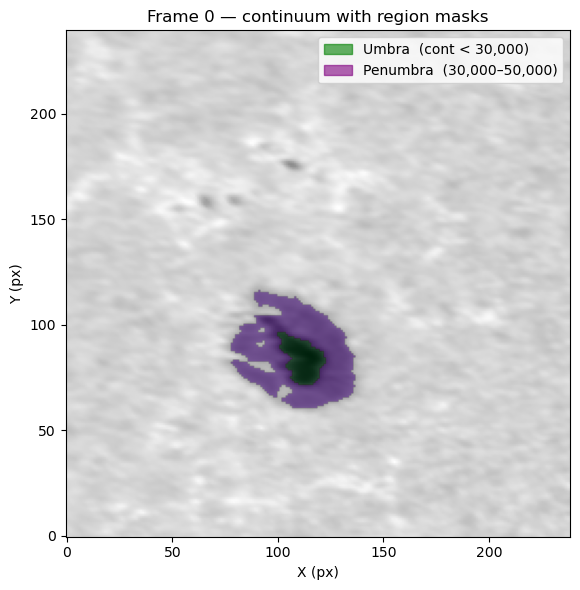

In [ ]:
plot_calibration_frame(
    data,
    frame_idx = 0,       # use None for the middle frame, or any integer
    save      = False,
    plots_dir = plots_dir_03,
)

Figure saved → ../data/processed/sebastian_sun_spots/DS03/plots/calibration_frame_0500.png


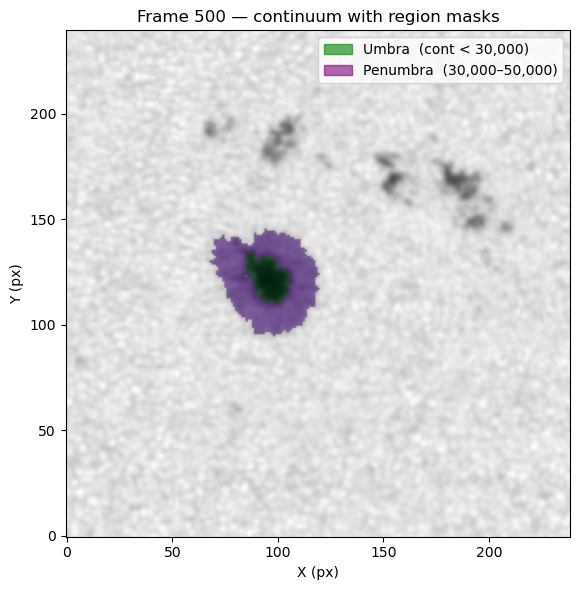

In [ ]:
# Intermediate frame check — useful when the sunspot evolves significantly
plot_calibration_frame(
    data,
    frame_idx = 500,
    save      = False,
    plots_dir = plots_dir_03,
)

## Step 3 — Compute per-frame metrics

In [9]:
metrics = compute_metrics(data)

n_pix = data['umbra'].sum(axis=(1, 2))
print(f"Umbra pixels/frame  →  mean={n_pix.mean():.0f}, min={n_pix.min()}, max={n_pix.max()}")
print(f"Mean B   umbra    : {np.nanmean(metrics['mean_mag_umb']):.1f} G")
print(f"Mean B   penumbra : {np.nanmean(metrics['mean_mag_pen']):.1f} G")
print(f"Mean v   umbra    : {np.nanmean(metrics['mean_dop_umb']):.1f} m/s")
print(f"Mean v   penumbra : {np.nanmean(metrics['mean_dop_pen']):.1f} m/s")

Umbra pixels/frame  →  mean=286, min=108, max=370
Mean B   umbra    : 1200.5 G
Mean B   penumbra : 452.7 G
Mean v   umbra    : -212.5 m/s
Mean v   penumbra : -299.1 m/s


## Step 4 — Save metrics CSV

In [10]:
save_metrics_csv(data, metrics, processed_dir_03)

Metrics saved → ../data/processed/sebastian_sun_spots/DS03/metrics.csv  (1084 rows)


PosixPath('../data/processed/sebastian_sun_spots/DS03/metrics.csv')

## Step 5 — Time-series plots

Figure saved → ../data/processed/sebastian_sun_spots/DS03/plots/time_series.png


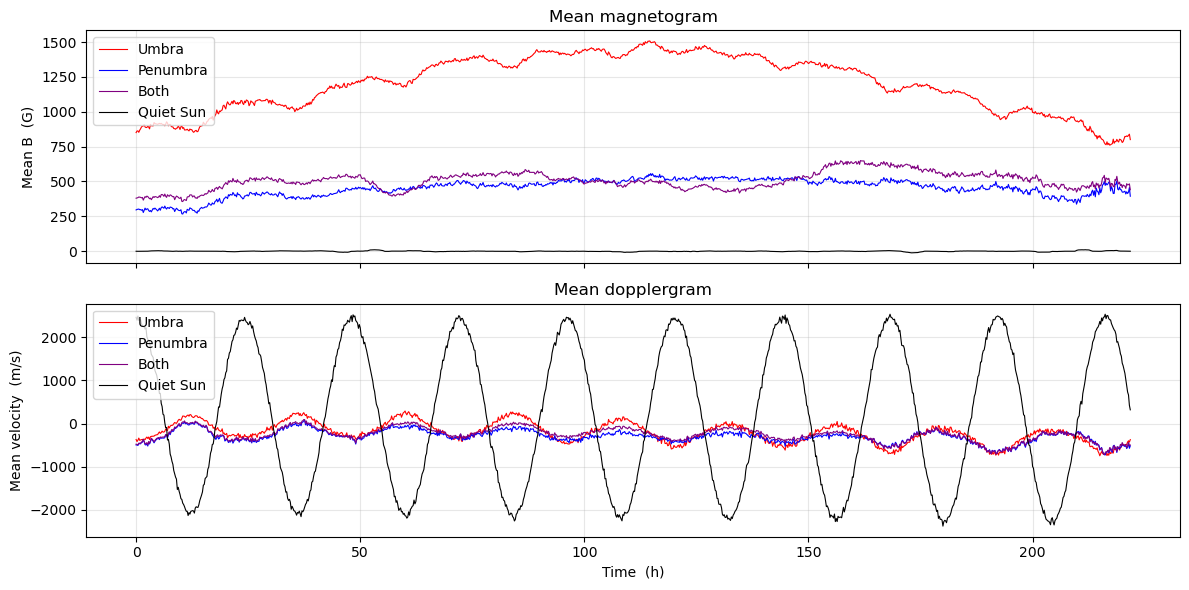

In [11]:
plot_time_series(data, metrics, save=True, plots_dir=plots_dir_03)

Figure saved → ../data/processed/sebastian_sun_spots/DS03/plots/time_series_normalized.png


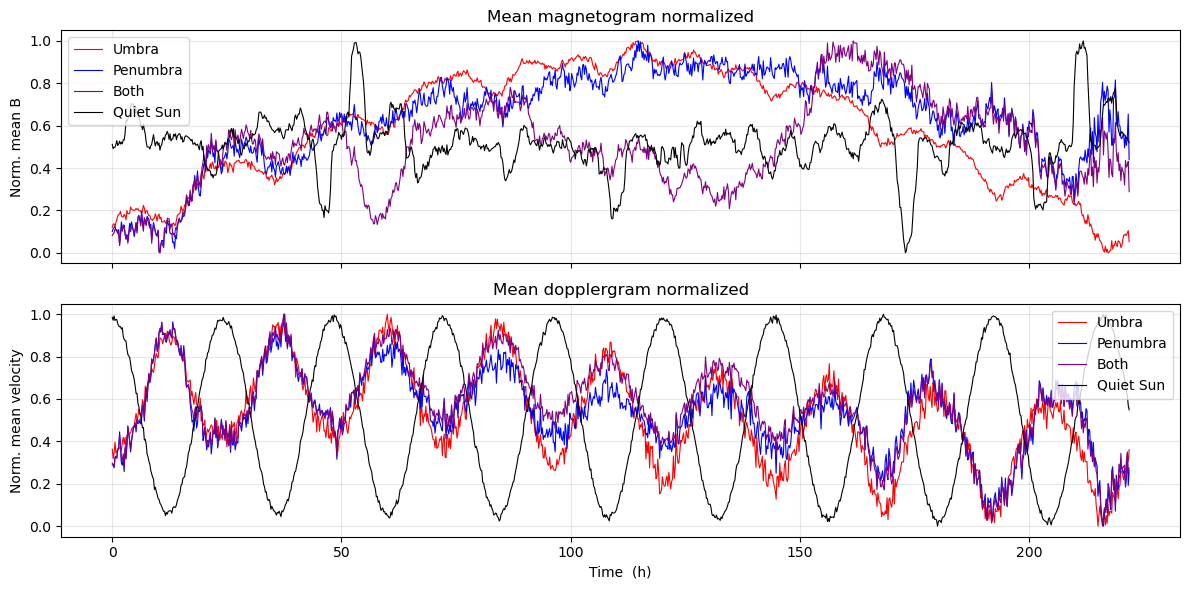

In [12]:
plot_time_series(data, metrics, normalized=True, save=True, plots_dir=plots_dir_03)

## Step 6 — FFT analysis

### 6a — Separate subplots (one per region)

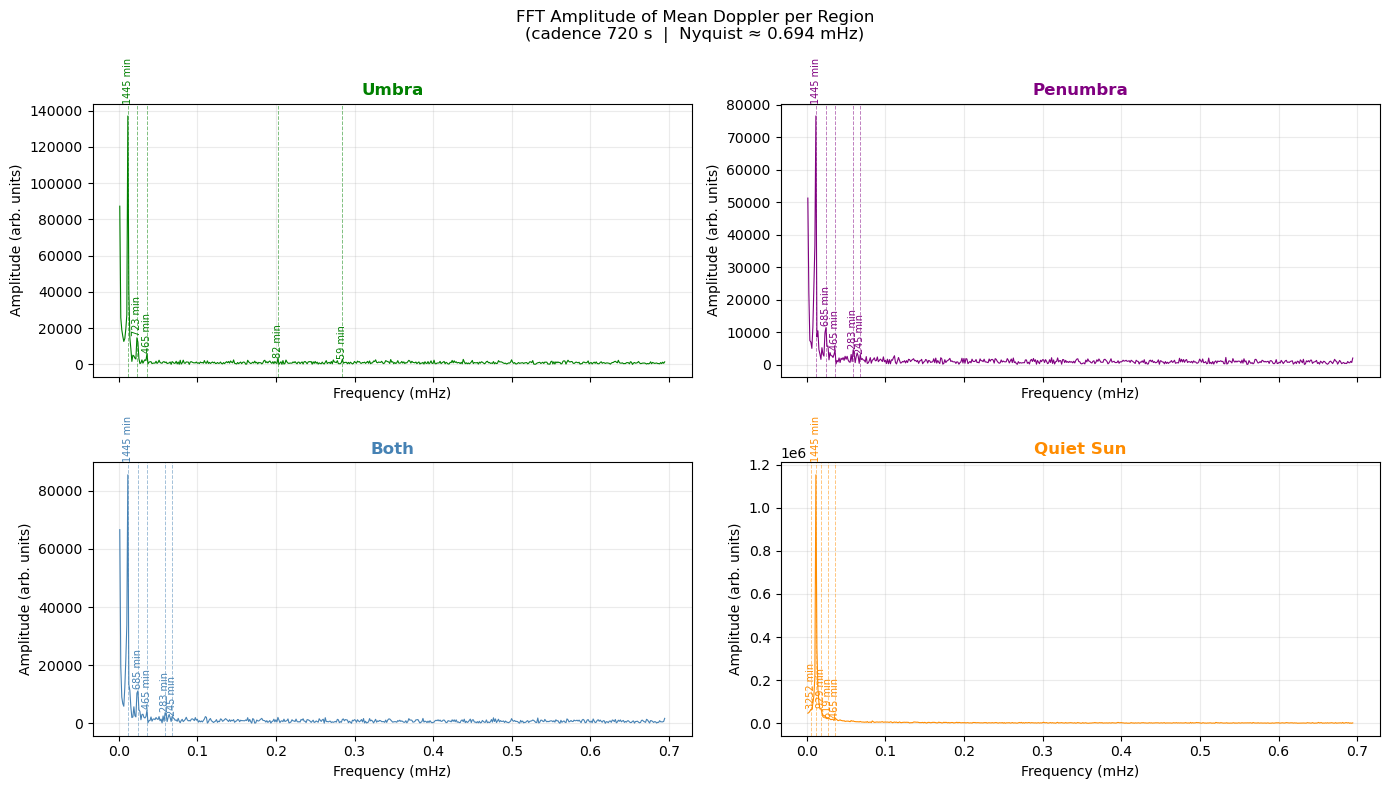


Region        Rank   Freq (mHz)   Period (min)  Rel. amplitude
────────────────────────────────────────────────────────────
Umbra            1       0.0115         1445.3          1.0000
Umbra            2       0.0231          722.7          0.1071
Umbra            3       0.0359          464.6          0.0435
Umbra            4       0.2024           82.3          0.0246
Umbra            5       0.2844           58.6          0.0212

Penumbra         1       0.0115         1445.3          1.0000
Penumbra         2       0.0243          684.6          0.1489
Penumbra         3       0.0589          282.8          0.0592
Penumbra         4       0.0359          464.6          0.0575
Penumbra         5       0.0679          245.4          0.0404

Both             1       0.0115         1445.3          1.0000
Both             2       0.0243          684.6          0.1306
Both             3       0.0359          464.6          0.0531
Both             4       0.0589          282.8        

In [13]:
plot_ffts_separate(
    data, metrics,
    annotate_peaks = True,
    print_table    = True,
    save           = False,
    plots_dir      = plots_dir_03,
)

### 6b — Combined plot with x-axis zoom

Adjust `xlim` to focus on the frequency range of interest (in mHz).  
The peak-table CSV (`fft_peaks.csv`) is saved alongside the figure.

Figure saved → ../data/processed/sebastian_sun_spots/DS03/plots/fft_combined.png


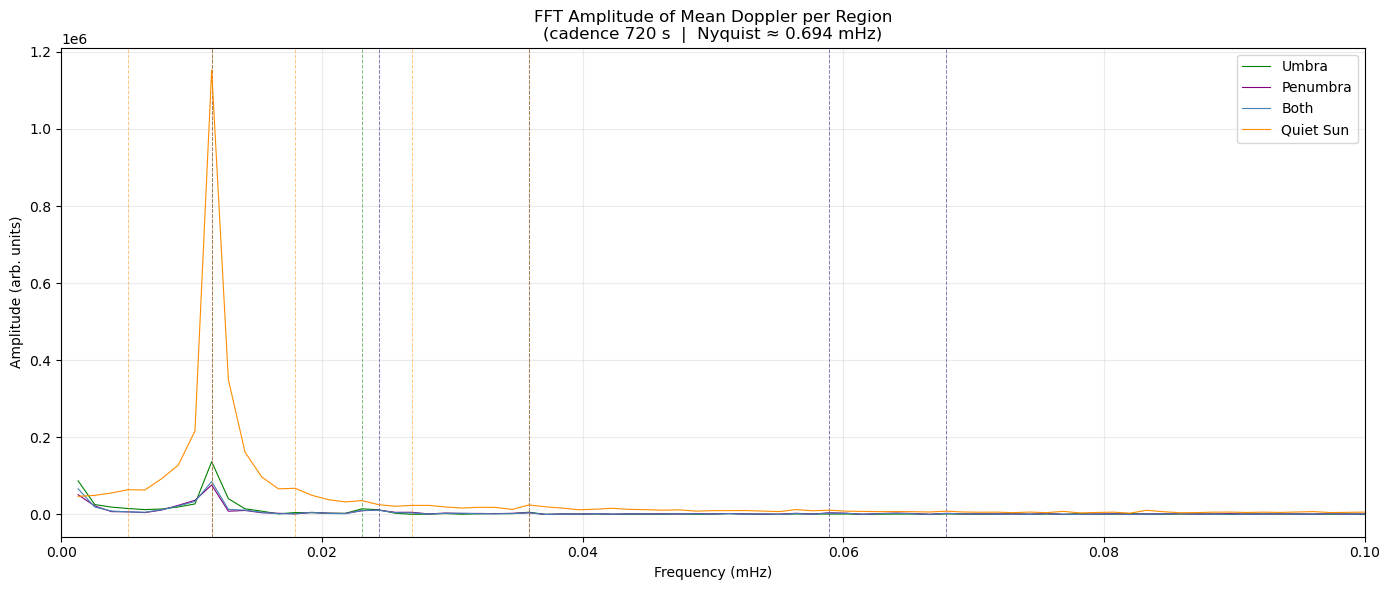


Region        Rank   Freq (mHz)   Period (min)  Rel. amplitude
────────────────────────────────────────────────────────────
Umbra            1       0.0115         1445.3          1.0000
Umbra            2       0.0231          722.7          0.1071
Umbra            3       0.0359          464.6          0.0435
Umbra            4       0.2024           82.3          0.0246
Umbra            5       0.2844           58.6          0.0212

Penumbra         1       0.0115         1445.3          1.0000
Penumbra         2       0.0243          684.6          0.1489
Penumbra         3       0.0589          282.8          0.0592
Penumbra         4       0.0359          464.6          0.0575
Penumbra         5       0.0679          245.4          0.0404

Both             1       0.0115         1445.3          1.0000
Both             2       0.0243          684.6          0.1306
Both             3       0.0359          464.6          0.0531
Both             4       0.0589          282.8        

In [14]:
plot_ffts_combined(
    data, metrics,
    xlim           = (0, 0.1),   # mHz — change or set to None for full range
    annotate_peaks = True,
    print_table    = True,
    save           = True,
    plots_dir      = plots_dir_03,
)

## Step 7 — Save animation

In [15]:
anim_path = processed_dir_03 / 'anim.html'

save_animation(
    data, metrics,
    save_path = anim_path,
    step      = 50,   # include every 50th frame
    fps       = 5,
)

Animation saved → ../data/processed/sebastian_sun_spots/DS03/anim.html


In [16]:
# Open the saved animation in the browser
from IPython.display import FileLink
FileLink(str(anim_path))


/home/thomas/Desktop/sun_spots_pulsation_review/data/processed/sebastian_sun_spots/DS03/anim.html

# DS04

In [17]:
# ── paths ─────────────────────────────────────────────────────────────────────
DS04_NAME      = 'DS04'
raw_dir_04      = pathlib.Path('../data/raw/sebastian_sun_spots') / DS04_NAME
processed_dir_04 = pathlib.Path('../data/processed/sebastian_sun_spots') / DS04_NAME
plots_dir_04    = processed_dir_04 / 'plots'

print('Raw data dir :', raw_dir_04)
print('Processed dir:', processed_dir_04)

Raw data dir : ../data/raw/sebastian_sun_spots/DS04
Processed dir: ../data/processed/sebastian_sun_spots/DS04


## Step 0 — Verify cadence from the `.sav` timing file

In [18]:
cadence_s, cadence_list = verify_cadence(raw_dir_04)
arr, counts = np.unique(cadence_list, return_counts=True)
dict(zip(arr, counts))

(median 720.0 s, max dev 720.00 s)


/home/thomas/Desktop/sun_spots_pulsation_review/src/sunspot_analysis.py:130: UserWarning: Cadence check failed: 21 gaps deviate from 720.0 s (max deviation 720.0 s)
  warnings.warn(


{np.float64(719.0): np.int64(4),
 np.float64(720.0): np.int64(1041),
 np.float64(721.0): np.int64(2),
 np.float64(1440.0): np.int64(21)}

## Step 1 — Load cubes and build region masks

Adjust `umbra_thresh` and `penumbra_thresh` after looking at the calibration frame below.
Run **Steps 1–2** together until the masks look right, then proceed.

In [19]:
data = load_and_mask(
    ds_dir          = raw_dir_04,
    umbra_thresh    = 30_000,   # continuum DN — pixels below this → umbra
    penumbra_thresh = 50_000,   # continuum DN — upper bound for penumbra
    cadence_s       = cadence_list,
)

print(f"Cube shape (n_t, ny, nx): {data['cube_cont'].shape}")
print(f"Time span: {data['time_h'][-1]:.1f} h  ({data['n_t']} frames @ {data['cadence_s']:.0f} s)")

Cube shape (n_t, ny, nx): (1069, 259, 239)
Time span: 217.8 h  (1069 frames @ 720 s)


## Step 2 — Calibration frame

Change `frame_idx` to inspect any frame.  
Green overlay = umbra, purple = penumbra.

Figure saved → ../data/processed/sebastian_sun_spots/DS04/plots/calibration_frame_0000.png


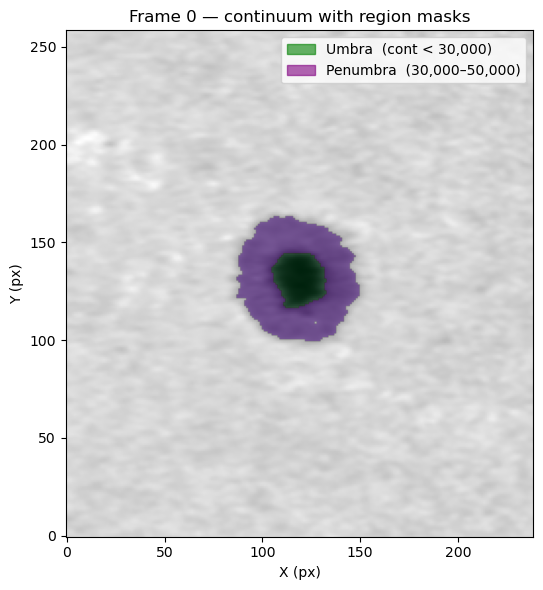

In [ ]:
plot_calibration_frame(
    data,
    frame_idx = 0,       # use None for the middle frame, or any integer
    save      = False,
    plots_dir = plots_dir_04,
)

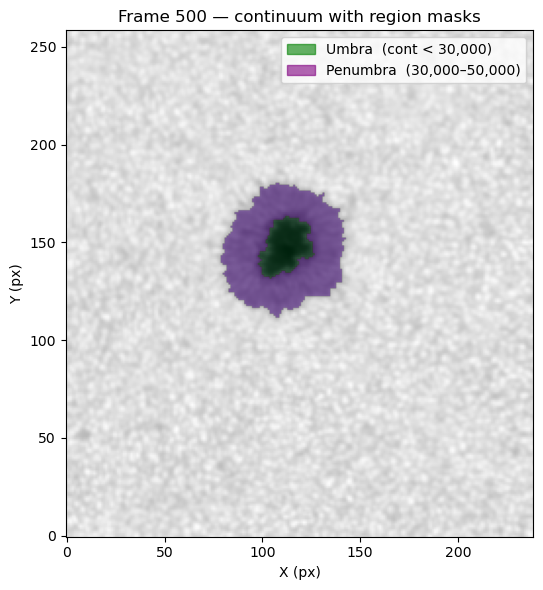

In [21]:
# Intermediate frame check — useful when the sunspot evolves significantly
plot_calibration_frame(
    data,
    frame_idx = 500,
    save      = False,
    plots_dir = plots_dir_04,
)

## Step 3 — Compute per-frame metrics

In [22]:
metrics = compute_metrics(data)

n_pix = data['umbra'].sum(axis=(1, 2))
print(f"Umbra pixels/frame  →  mean={n_pix.mean():.0f}, min={n_pix.min()}, max={n_pix.max()}")
print(f"Mean B   umbra    : {np.nanmean(metrics['mean_mag_umb']):.1f} G")
print(f"Mean B   penumbra : {np.nanmean(metrics['mean_mag_pen']):.1f} G")
print(f"Mean v   umbra    : {np.nanmean(metrics['mean_dop_umb']):.1f} m/s")
print(f"Mean v   penumbra : {np.nanmean(metrics['mean_dop_pen']):.1f} m/s")

Umbra pixels/frame  →  mean=541, min=390, max=619
Mean B   umbra    : -1271.7 G
Mean B   penumbra : -405.4 G
Mean v   umbra    : -72.3 m/s
Mean v   penumbra : -216.8 m/s


## Step 4 — Save metrics CSV

In [23]:
save_metrics_csv(data, metrics, processed_dir_04)

Metrics saved → ../data/processed/sebastian_sun_spots/DS04/metrics.csv  (1069 rows)


PosixPath('../data/processed/sebastian_sun_spots/DS04/metrics.csv')

## Step 5 — Time-series plots

Figure saved → ../data/processed/sebastian_sun_spots/DS04/plots/time_series.png


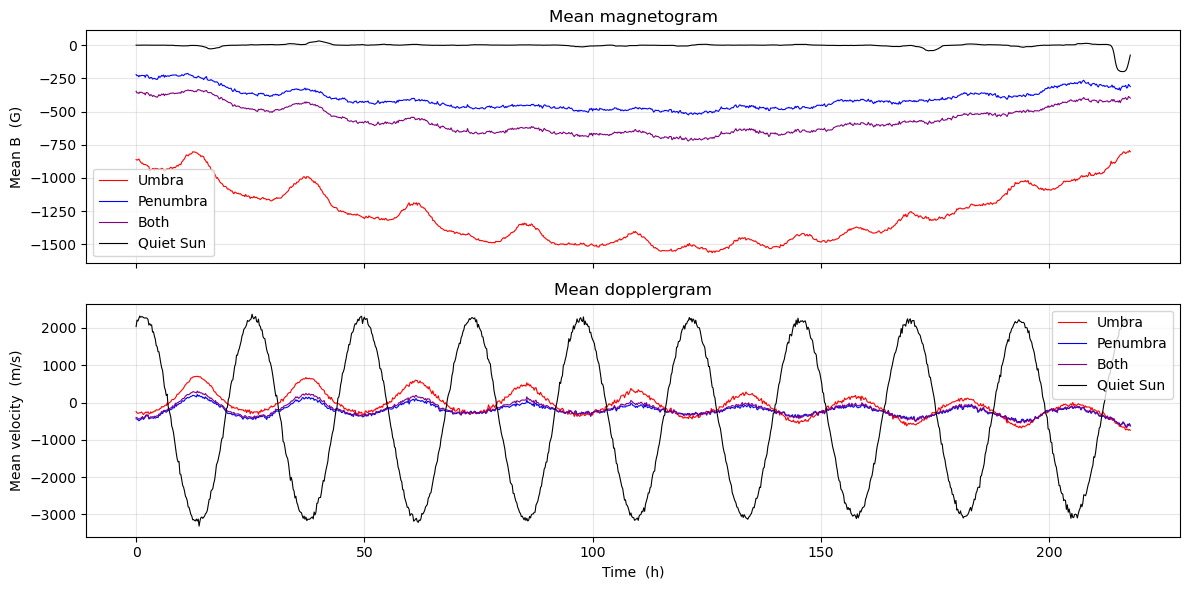

In [24]:
plot_time_series(data, metrics, save=True, plots_dir=plots_dir_04)

Figure saved → ../data/processed/sebastian_sun_spots/DS04/plots/time_series_normalized.png


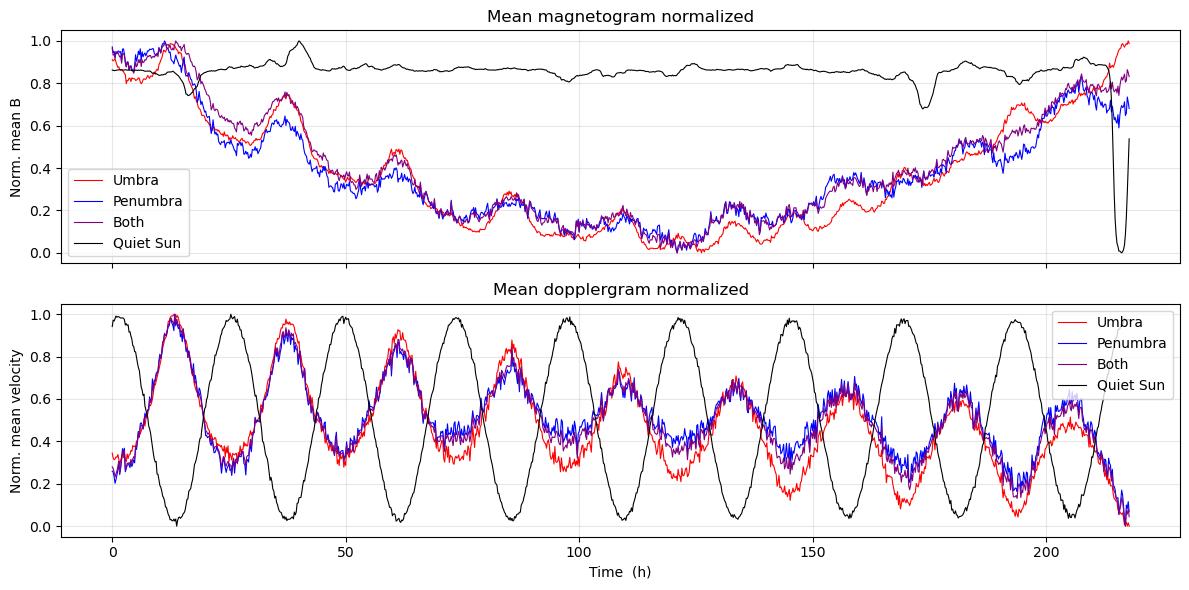

In [25]:
plot_time_series(data, metrics, normalized=True, save=True, plots_dir=plots_dir_04)

## Step 6 — FFT analysis

### 6a — Separate subplots (one per region)

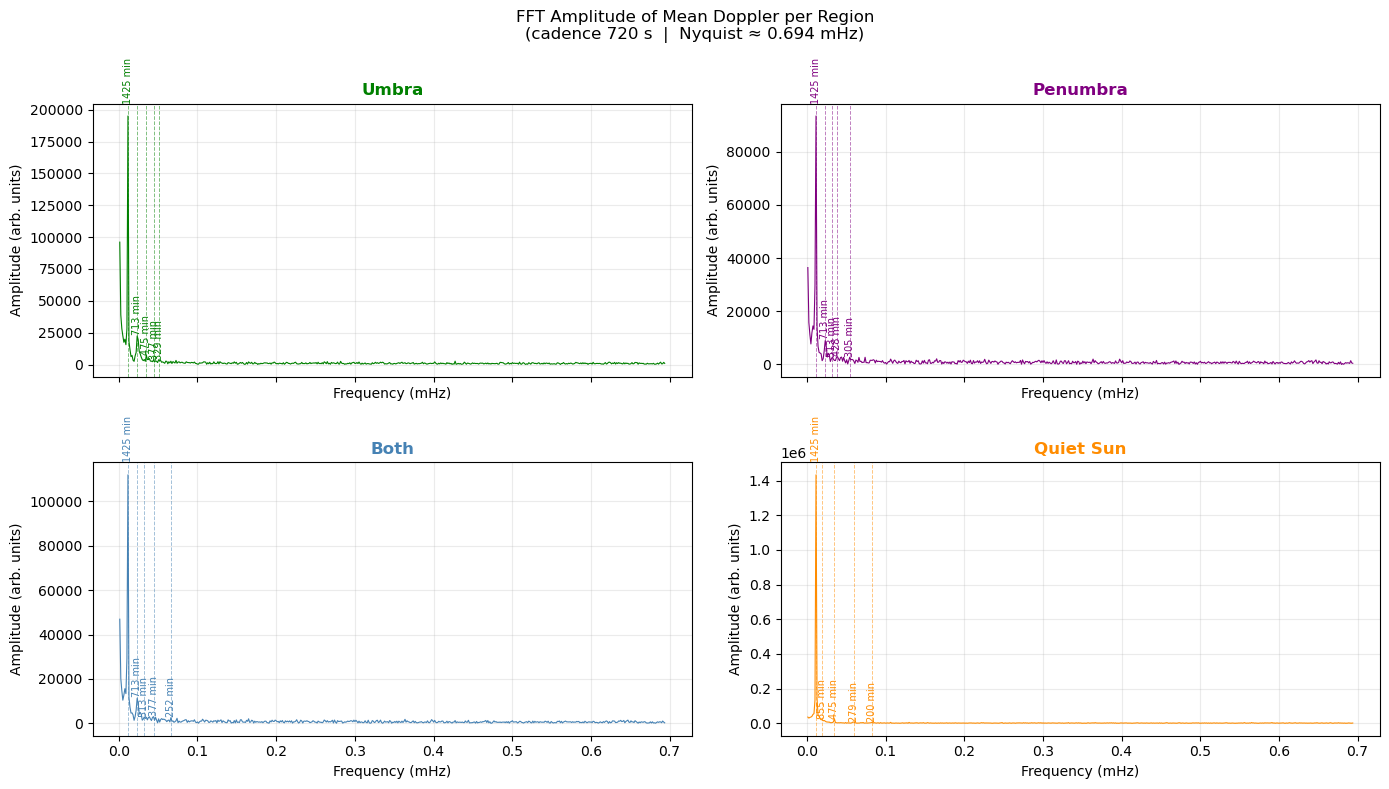


Region        Rank   Freq (mHz)   Period (min)  Rel. amplitude
────────────────────────────────────────────────────────────
Umbra            1       0.0117         1425.3          1.0000
Umbra            2       0.0234          712.7          0.1149
Umbra            3       0.0351          475.1          0.0379
Umbra            4       0.0507          328.9          0.0191
Umbra            5       0.0442          377.3          0.0181

Penumbra         1       0.0117         1425.3          1.0000
Penumbra         2       0.0234          712.7          0.0957
Penumbra         3       0.0390          427.6          0.0311
Penumbra         4       0.0325          513.1          0.0293
Penumbra         5       0.0546          305.4          0.0290

Both             1       0.0117         1425.3          1.0000
Both             2       0.0234          712.7          0.1012
Both             3       0.0442          377.3          0.0270
Both             4       0.0325          513.1        

In [26]:
plot_ffts_separate(
    data, metrics,
    annotate_peaks = True,
    print_table    = True,
    save           = False,
    plots_dir      = plots_dir_04,
)

### 6b — Combined plot with x-axis zoom

Adjust `xlim` to focus on the frequency range of interest (in mHz).  
The peak-table CSV (`fft_peaks.csv`) is saved alongside the figure.

Figure saved → ../data/processed/sebastian_sun_spots/DS04/plots/fft_combined.png


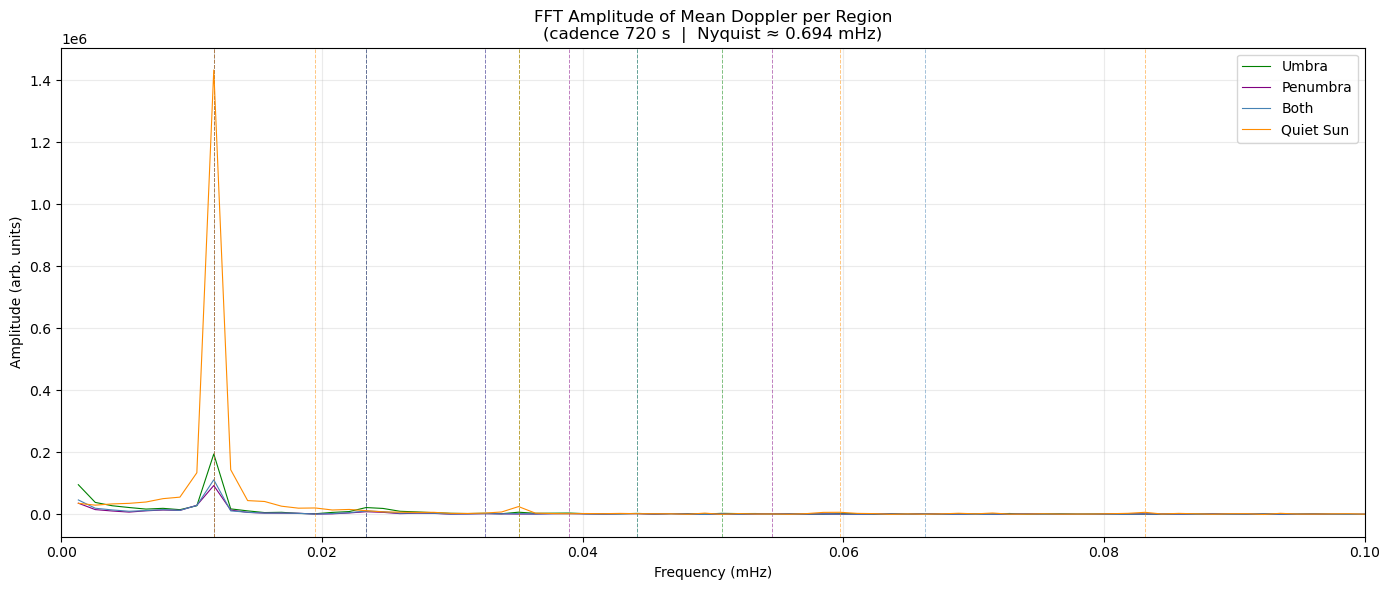


Region        Rank   Freq (mHz)   Period (min)  Rel. amplitude
────────────────────────────────────────────────────────────
Umbra            1       0.0117         1425.3          1.0000
Umbra            2       0.0234          712.7          0.1149
Umbra            3       0.0351          475.1          0.0379
Umbra            4       0.0507          328.9          0.0191
Umbra            5       0.0442          377.3          0.0181

Penumbra         1       0.0117         1425.3          1.0000
Penumbra         2       0.0234          712.7          0.0957
Penumbra         3       0.0390          427.6          0.0311
Penumbra         4       0.0325          513.1          0.0293
Penumbra         5       0.0546          305.4          0.0290

Both             1       0.0117         1425.3          1.0000
Both             2       0.0234          712.7          0.1012
Both             3       0.0442          377.3          0.0270
Both             4       0.0325          513.1        

In [27]:
plot_ffts_combined(
    data, metrics,
    xlim           = (0, 0.1),   # mHz — change or set to None for full range
    annotate_peaks = True,
    print_table    = True,
    save           = True,
    plots_dir      = plots_dir_04,
)

## Step 7 — Save animation

In [28]:
anim_path = processed_dir_04 / 'anim.html'

save_animation(
    data, metrics,
    save_path = anim_path,
    step      = 50,   # include every 50th frame
    fps       = 5,
)

Animation saved → ../data/processed/sebastian_sun_spots/DS04/anim.html


In [29]:
# Open the saved animation in the browser
from IPython.display import FileLink
FileLink(str(anim_path))


/home/thomas/Desktop/sun_spots_pulsation_review/data/processed/sebastian_sun_spots/DS04/anim.html

# DS05

In [30]:
# ── paths ─────────────────────────────────────────────────────────────────────
DS05_NAME      = 'DS05'
raw_dir_05      = pathlib.Path('../data/raw/sebastian_sun_spots') / DS05_NAME
processed_dir_05 = pathlib.Path('../data/processed/sebastian_sun_spots') / DS05_NAME
plots_dir_05    = processed_dir_05 / 'plots'

print('Raw data dir :', raw_dir_05)
print('Processed dir:', processed_dir_05)

Raw data dir : ../data/raw/sebastian_sun_spots/DS05
Processed dir: ../data/processed/sebastian_sun_spots/DS05


## Step 0 — Verify cadence from the `.sav` timing file

In [32]:
cadence_s, cadence_list = verify_cadence(raw_dir_05)
arr, counts = np.unique(cadence_list, return_counts=True)
dict(zip(arr, counts))
cadence_list =abs(cadence_list)

(median 720.0 s, max dev 262800.00 s)


/home/thomas/Desktop/sun_spots_pulsation_review/src/sunspot_analysis.py:130: UserWarning: Cadence check failed: 24 gaps deviate from 720.0 s (max deviation 262800.0 s)
  warnings.warn(


## Step 1 — Load cubes and build region masks

Adjust `umbra_thresh` and `penumbra_thresh` after looking at the calibration frame below.
Run **Steps 1–2** together until the masks look right, then proceed.

In [40]:
data = load_and_mask(
    ds_dir          = raw_dir_05,
    umbra_thresh    = 30_000,   # continuum DN — pixels below this → umbra
    penumbra_thresh = 50_000,   # continuum DN — upper bound for penumbra
    cadence_s       = 720,
)

print(f"Cube shape (n_t, ny, nx): {data['cube_cont'].shape}")
print(f"Time span: {data['time_h'][-1]:.1f} h  ({data['n_t']} frames @ {data['cadence_s']:.0f} s)")

Cube shape (n_t, ny, nx): (1088, 219, 249)
Time span: 217.4 h  (1088 frames @ 720 s)


## Step 2 — Calibration frame

Change `frame_idx` to inspect any frame.  
Green overlay = umbra, purple = penumbra.

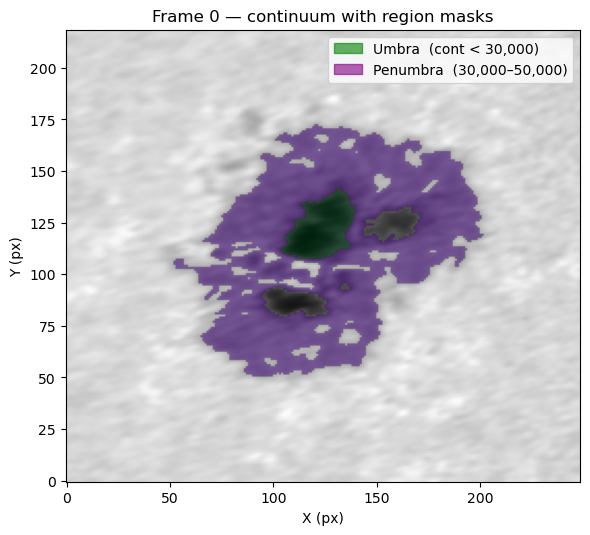

In [41]:
plot_calibration_frame(
    data,
    frame_idx = 0,       # use None for the middle frame, or any integer
    save      = False,
    plots_dir = plots_dir_05,
)

Figure saved → ../data/processed/sebastian_sun_spots/DS05/plots/calibration_frame_0500.png


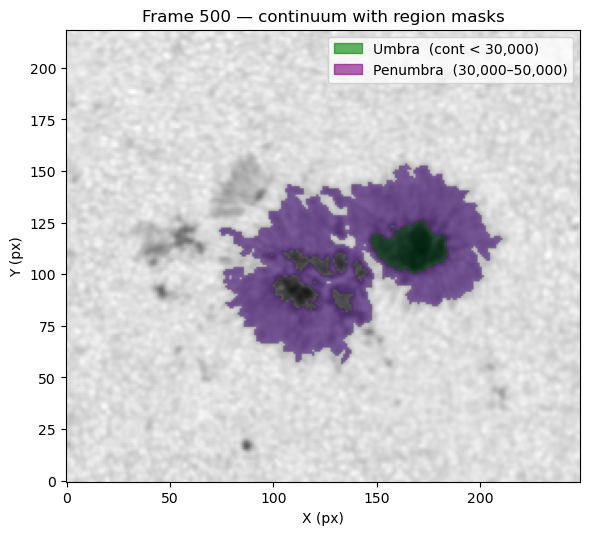

In [36]:
# Intermediate frame check — useful when the sunspot evolves significantly
plot_calibration_frame(
    data,
    frame_idx = 500,
    save      = True,
    plots_dir = plots_dir_05,
)

## Step 3 — Compute per-frame metrics

In [42]:
metrics = compute_metrics(data)

n_pix = data['umbra'].sum(axis=(1, 2))
print(f"Umbra pixels/frame  →  mean={n_pix.mean():.0f}, min={n_pix.min()}, max={n_pix.max()}")
print(f"Mean B   umbra    : {np.nanmean(metrics['mean_mag_umb']):.1f} G")
print(f"Mean B   penumbra : {np.nanmean(metrics['mean_mag_pen']):.1f} G")
print(f"Mean v   umbra    : {np.nanmean(metrics['mean_dop_umb']):.1f} m/s")
print(f"Mean v   penumbra : {np.nanmean(metrics['mean_dop_pen']):.1f} m/s")

Umbra pixels/frame  →  mean=586, min=226, max=1447
Mean B   umbra    : 1136.8 G
Mean B   penumbra : 465.8 G
Mean v   umbra    : -22.9 m/s
Mean v   penumbra : -247.5 m/s


## Step 4 — Save metrics CSV

In [43]:
save_metrics_csv(data, metrics, processed_dir_05)

Metrics saved → ../data/processed/sebastian_sun_spots/DS05/metrics.csv  (1088 rows)


PosixPath('../data/processed/sebastian_sun_spots/DS05/metrics.csv')

## Step 5 — Time-series plots

Figure saved → ../data/processed/sebastian_sun_spots/DS05/plots/time_series.png


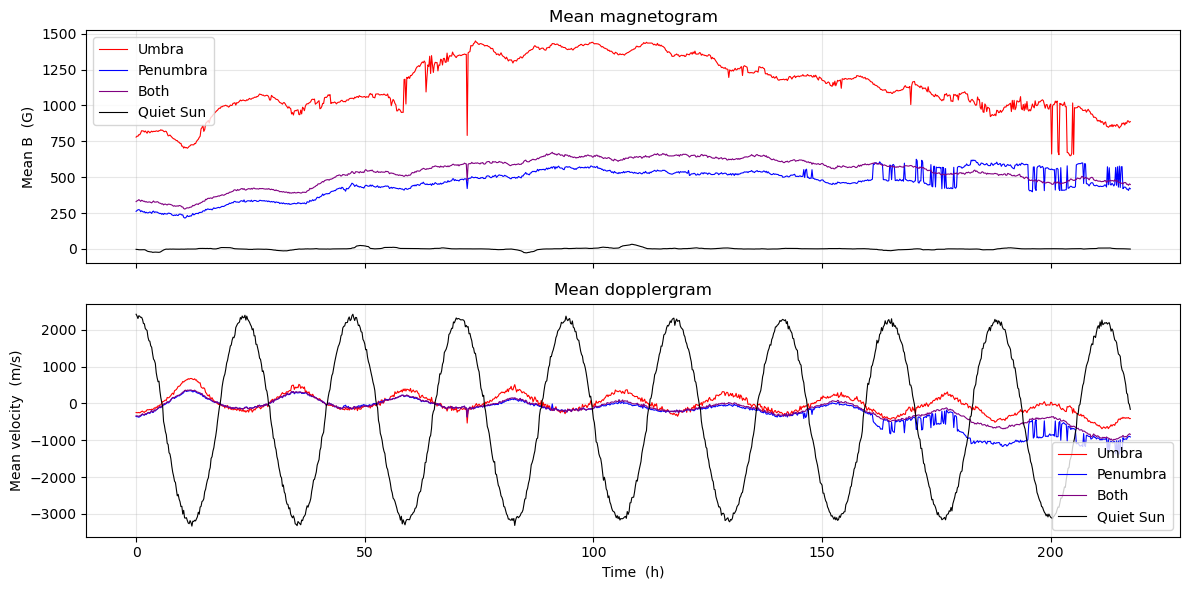

In [44]:
plot_time_series(data, metrics, save=True, plots_dir=plots_dir_05)

Figure saved → ../data/processed/sebastian_sun_spots/DS05/plots/time_series_normalized.png


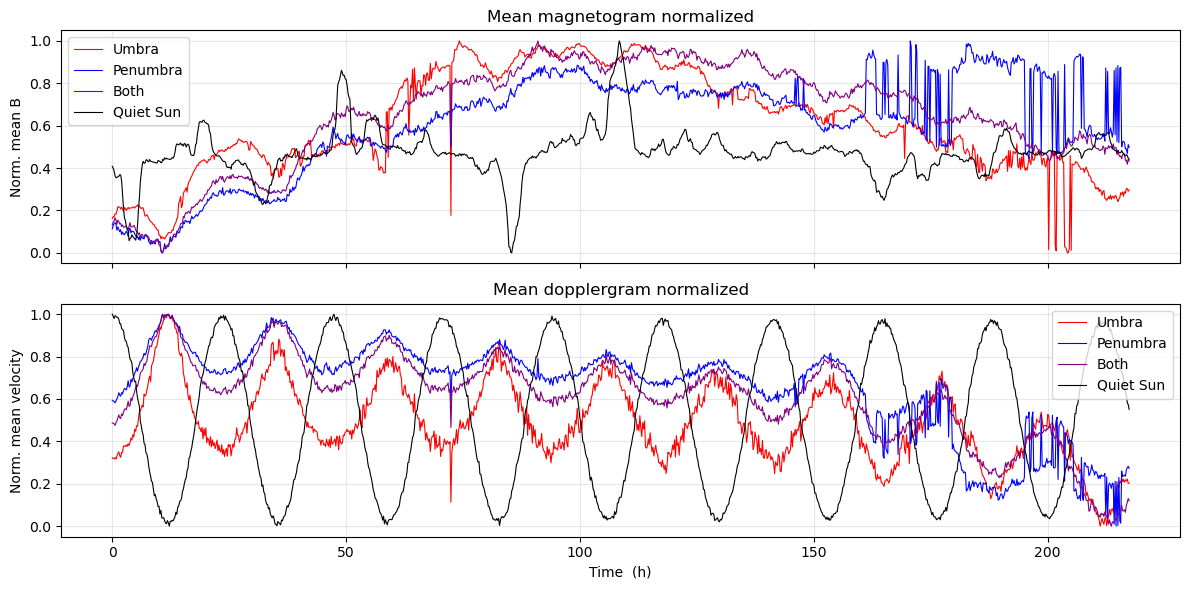

In [45]:
plot_time_series(data, metrics, normalized=True, save=True, plots_dir=plots_dir_05)

## Step 6 — FFT analysis

### 6a — Separate subplots (one per region)

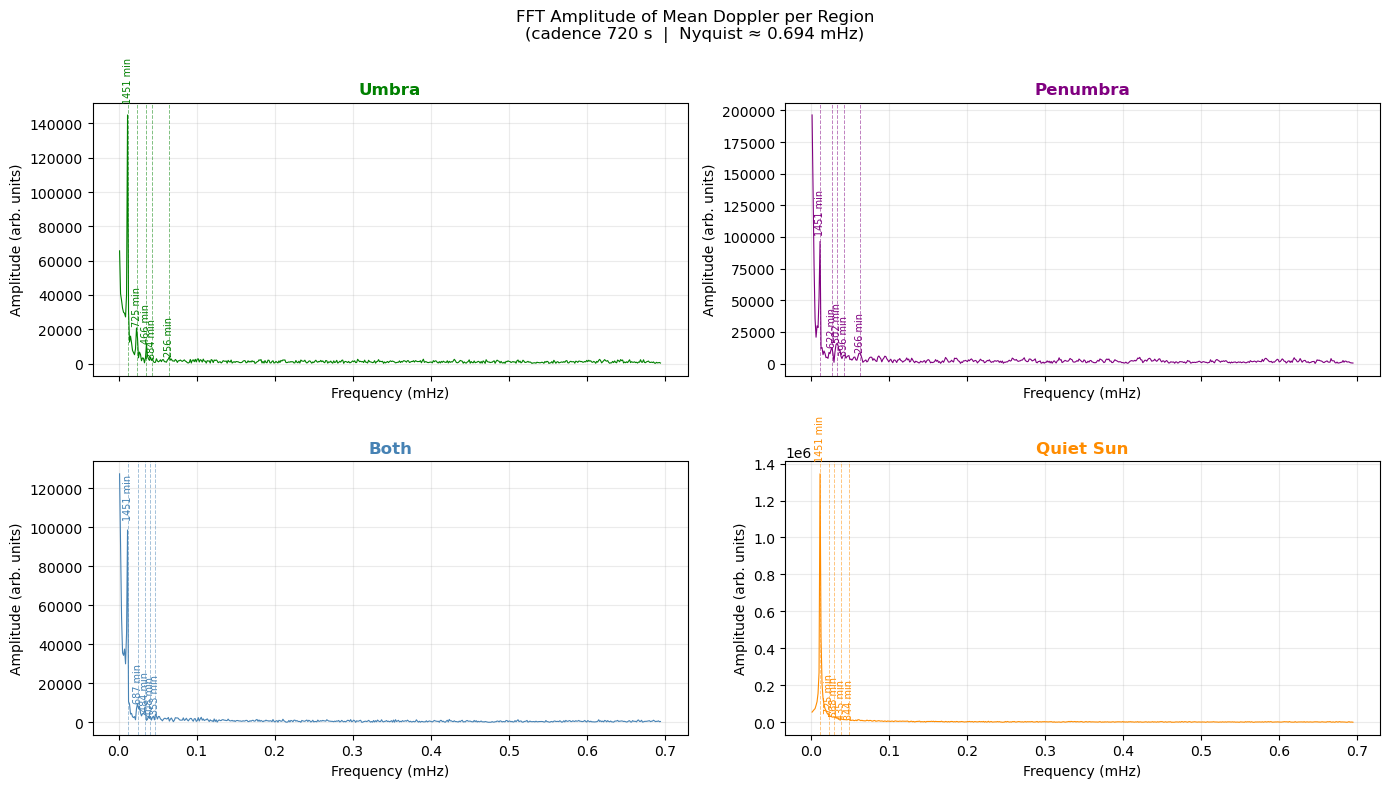


Region        Rank   Freq (mHz)   Period (min)  Rel. amplitude
────────────────────────────────────────────────────────────
Umbra            1       0.0115         1450.7          1.0000
Umbra            2       0.0230          725.3          0.1432
Umbra            3       0.0357          466.3          0.0790
Umbra            4       0.0651          256.0          0.0278
Umbra            5       0.0434          384.0          0.0199

Penumbra         1       0.0115         1450.7          0.4910
Penumbra         2       0.0332          502.2          0.0809
Penumbra         3       0.0268          621.7          0.0639
Penumbra         4       0.0626          266.4          0.0426
Penumbra         5       0.0421          395.6          0.0335

Both             1       0.0115         1450.7          0.7741
Both             2       0.0243          687.2          0.0749
Both             3       0.0345          483.6          0.0448
Both             4       0.0472          352.9        

In [46]:
plot_ffts_separate(
    data, metrics,
    annotate_peaks = True,
    print_table    = True,
    save           = False,
    plots_dir      = plots_dir_05,
)

### 6b — Combined plot with x-axis zoom

Adjust `xlim` to focus on the frequency range of interest (in mHz).  
The peak-table CSV (`fft_peaks.csv`) is saved alongside the figure.

Figure saved → ../data/processed/sebastian_sun_spots/DS05/plots/fft_combined.png


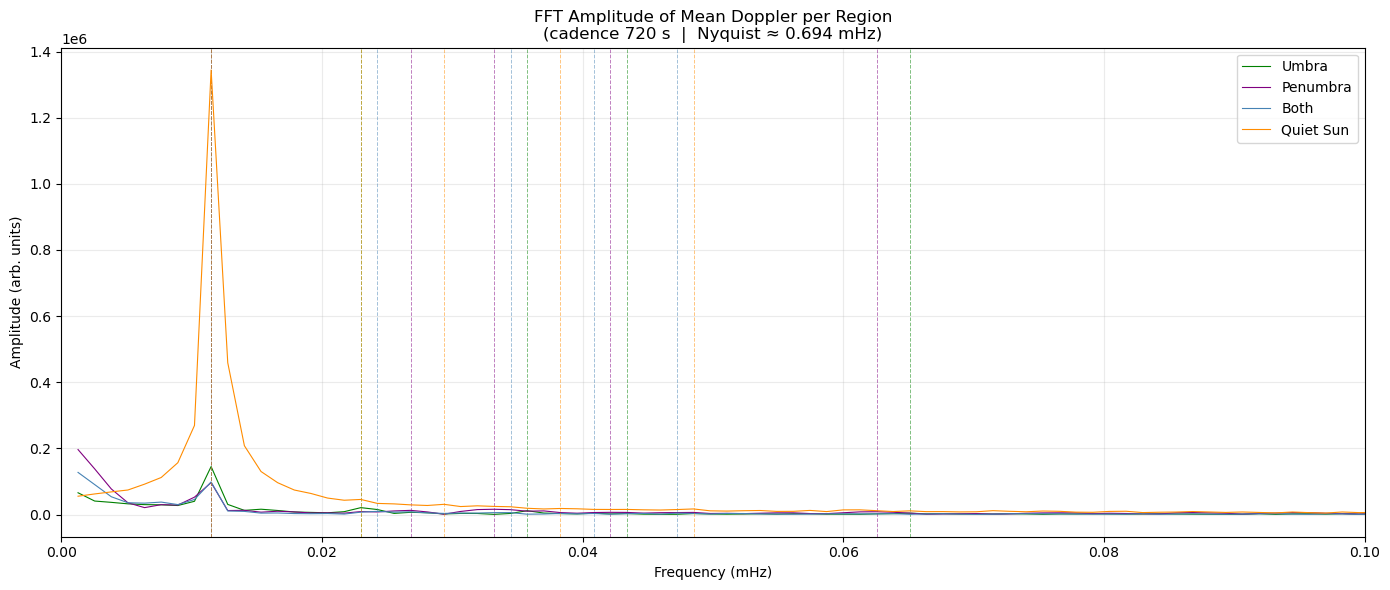


Region        Rank   Freq (mHz)   Period (min)  Rel. amplitude
────────────────────────────────────────────────────────────
Umbra            1       0.0115         1450.7          1.0000
Umbra            2       0.0230          725.3          0.1432
Umbra            3       0.0357          466.3          0.0790
Umbra            4       0.0651          256.0          0.0278
Umbra            5       0.0434          384.0          0.0199

Penumbra         1       0.0115         1450.7          0.4910
Penumbra         2       0.0332          502.2          0.0809
Penumbra         3       0.0268          621.7          0.0639
Penumbra         4       0.0626          266.4          0.0426
Penumbra         5       0.0421          395.6          0.0335

Both             1       0.0115         1450.7          0.7741
Both             2       0.0243          687.2          0.0749
Both             3       0.0345          483.6          0.0448
Both             4       0.0472          352.9        

In [47]:
plot_ffts_combined(
    data, metrics,
    xlim           = (0, 0.1),   # mHz — change or set to None for full range
    annotate_peaks = True,
    print_table    = True,
    save           = True,
    plots_dir      = plots_dir_05,
)

## Step 7 — Save animation

In [48]:
anim_path = processed_dir_05 / 'anim.html'

save_animation(
    data, metrics,
    save_path = anim_path,
    step      = 50,   # include every 50th frame
    fps       = 5,
)

Animation saved → ../data/processed/sebastian_sun_spots/DS05/anim.html


In [49]:
# Open the saved animation in the browser
from IPython.display import FileLink
FileLink(str(anim_path))


/home/thomas/Desktop/sun_spots_pulsation_review/data/processed/sebastian_sun_spots/DS05/anim.html

# DS06

In [2]:
# ── paths ─────────────────────────────────────────────────────────────────────
DS06_NAME      = 'DS06'
raw_dir_06      = pathlib.Path('../data/raw/sebastian_sun_spots') / DS06_NAME
processed_dir_06 = pathlib.Path('../data/processed/sebastian_sun_spots') / DS06_NAME
plots_dir_06    = processed_dir_06 / 'plots'

print('Raw data dir :', raw_dir_06)
print('Processed dir:', processed_dir_06)

Raw data dir : ../data/raw/sebastian_sun_spots/DS06
Processed dir: ../data/processed/sebastian_sun_spots/DS06


## Step 0 — Verify cadence from the `.sav` timing file

In [3]:
cadence_s, cadence_list = verify_cadence(raw_dir_06)
arr, counts = np.unique(cadence_list, return_counts=True)
dict(zip(arr, counts))

(median 720.0 s, max dev 10800.00 s)


/home/thomas/Desktop/sun_spots_pulsation_review/src/sunspot_analysis.py:130: UserWarning: Cadence check failed: 42 gaps deviate from 720.0 s (max deviation 10800.0 s)
  warnings.warn(


{np.float64(719.0): np.int64(5),
 np.float64(720.0): np.int64(907),
 np.float64(721.0): np.int64(3),
 np.float64(1440.0): np.int64(30),
 np.float64(7920.0): np.int64(3),
 np.float64(8640.0): np.int64(3),
 np.float64(9360.0): np.int64(2),
 np.float64(10080.0): np.int64(2),
 np.float64(10800.0): np.int64(1),
 np.float64(11520.0): np.int64(1)}

## Step 1 — Load cubes and build region masks

Adjust `umbra_thresh` and `penumbra_thresh` after looking at the calibration frame below.
Run **Steps 1–2** together until the masks look right, then proceed.

In [4]:
data = load_and_mask(
    ds_dir          = raw_dir_06,
    umbra_thresh    = 30_000,   # continuum DN — pixels below this → umbra
    penumbra_thresh = 50_000,   # continuum DN — upper bound for penumbra
    cadence_s       = cadence_list,
    filter_mask = False
)

print(f"Cube shape (n_t, ny, nx): {data['cube_cont'].shape}")
print(f"Time span: {data['time_h'][-1]:.1f} h  ({data['n_t']} frames @ {data['cadence_s']:.0f} s)")

Cube shape (n_t, ny, nx): (958, 239, 477)
Time span: 225.8 h  (958 frames @ 720 s)


## Step 2 — Calibration frame

Change `frame_idx` to inspect any frame.  
Green overlay = umbra, purple = penumbra.

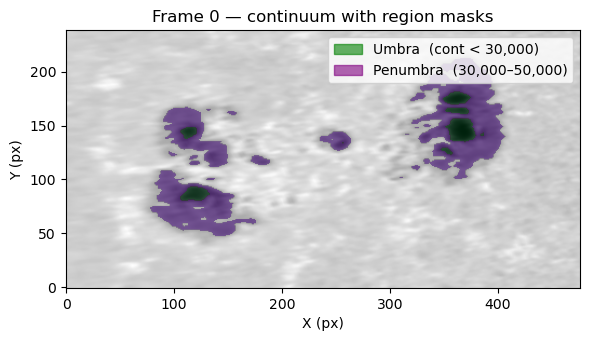

In [6]:
plot_calibration_frame(
    data,
    frame_idx = 0,       # use None for the middle frame, or any integer
    save      = False,
    plots_dir = plots_dir_06,
)

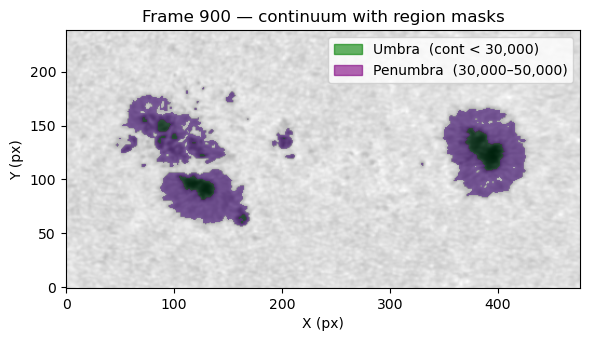

In [7]:
# Intermediate frame check — useful when the sunspot evolves significantly
plot_calibration_frame(
    data,
    frame_idx = 900,
    save      = False,
    plots_dir = plots_dir_06,
)

## Step 3 — Compute per-frame metrics

In [13]:
metrics = compute_metrics(data)

n_pix = data['umbra'].sum(axis=(1, 2))
print(f"Umbra pixels/frame  →  mean={n_pix.mean():.0f}, min={n_pix.min()}, max={n_pix.max()}")
print(f"Mean B   umbra    : {np.nanmean(metrics['mean_mag_umb']):.1f} G")
print(f"Mean B   penumbra : {np.nanmean(metrics['mean_mag_pen']):.1f} G")
print(f"Mean v   umbra    : {np.nanmean(metrics['mean_dop_umb']):.1f} m/s")
print(f"Mean v   penumbra : {np.nanmean(metrics['mean_dop_pen']):.1f} m/s")

Umbra pixels/frame  →  mean=1861, min=1185, max=2479
Mean B   umbra    : -91.8 G
Mean B   penumbra : 43.0 G
Mean v   umbra    : -44.3 m/s
Mean v   penumbra : -136.0 m/s


## Step 4 — Save metrics CSV

In [9]:
save_metrics_csv(data, metrics, processed_dir_06)

Metrics saved → ../data/processed/sebastian_sun_spots/DS06/metrics.csv  (958 rows)


PosixPath('../data/processed/sebastian_sun_spots/DS06/metrics.csv')

## Step 5 — Time-series plots

Figure saved → ../data/processed/sebastian_sun_spots/DS06/plots/time_series.png


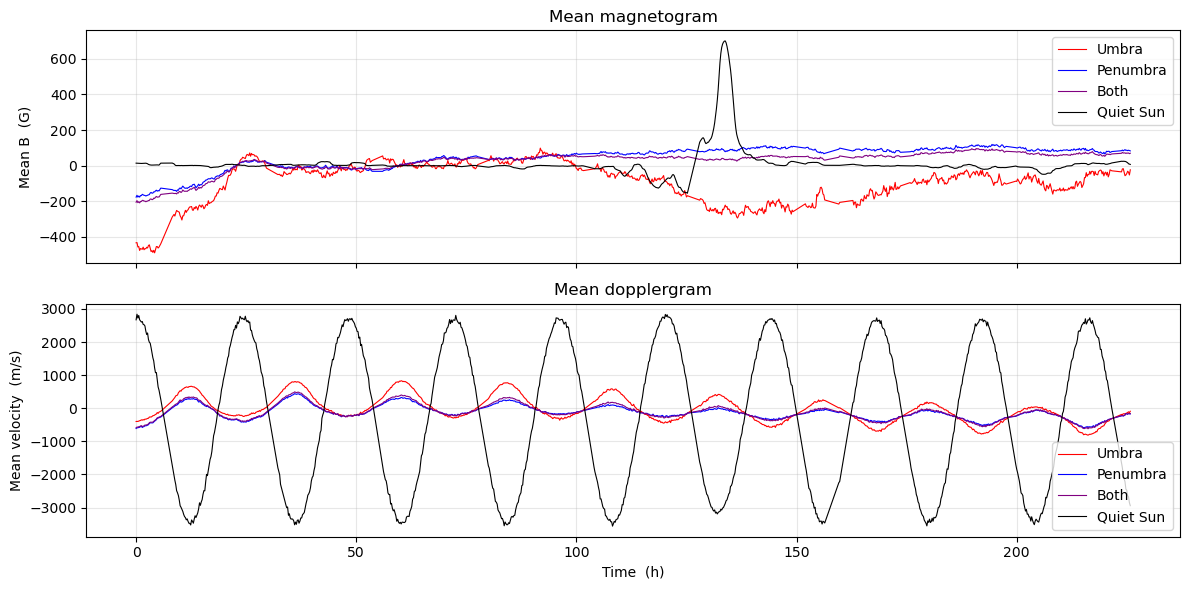

In [14]:
plot_time_series(data, metrics, save=True, plots_dir=plots_dir_06)

Figure saved → ../data/processed/sebastian_sun_spots/DS06/plots/time_series_normalized.png


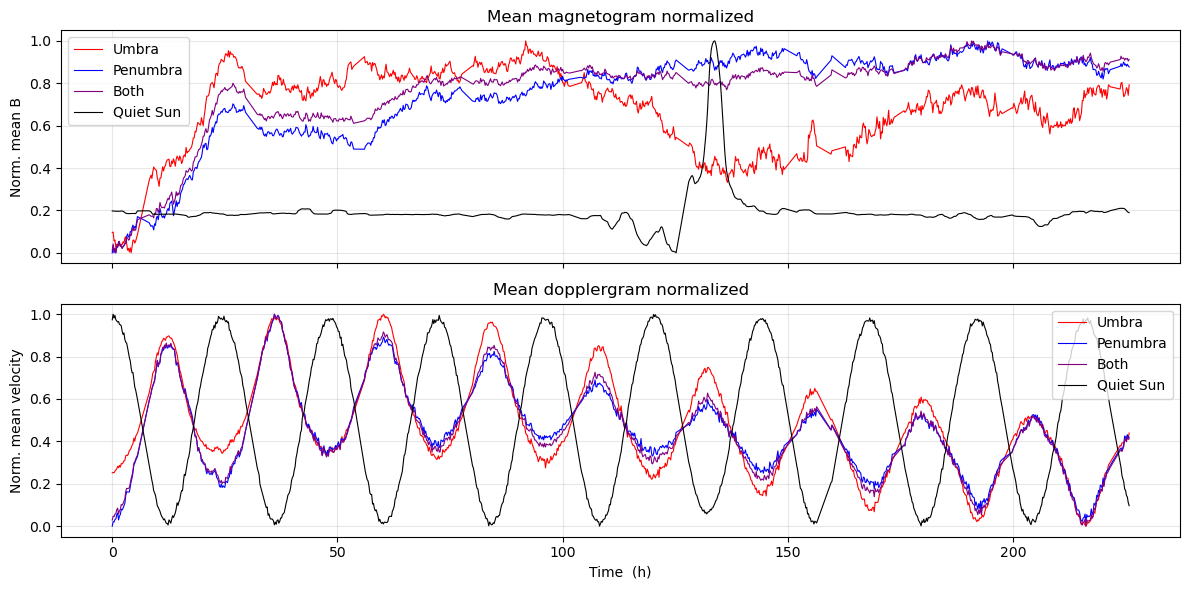

In [11]:
plot_time_series(data, metrics, normalized=True, save=True, plots_dir=plots_dir_06)

## Step 6 — FFT analysis

### 6a — Separate subplots (one per region)

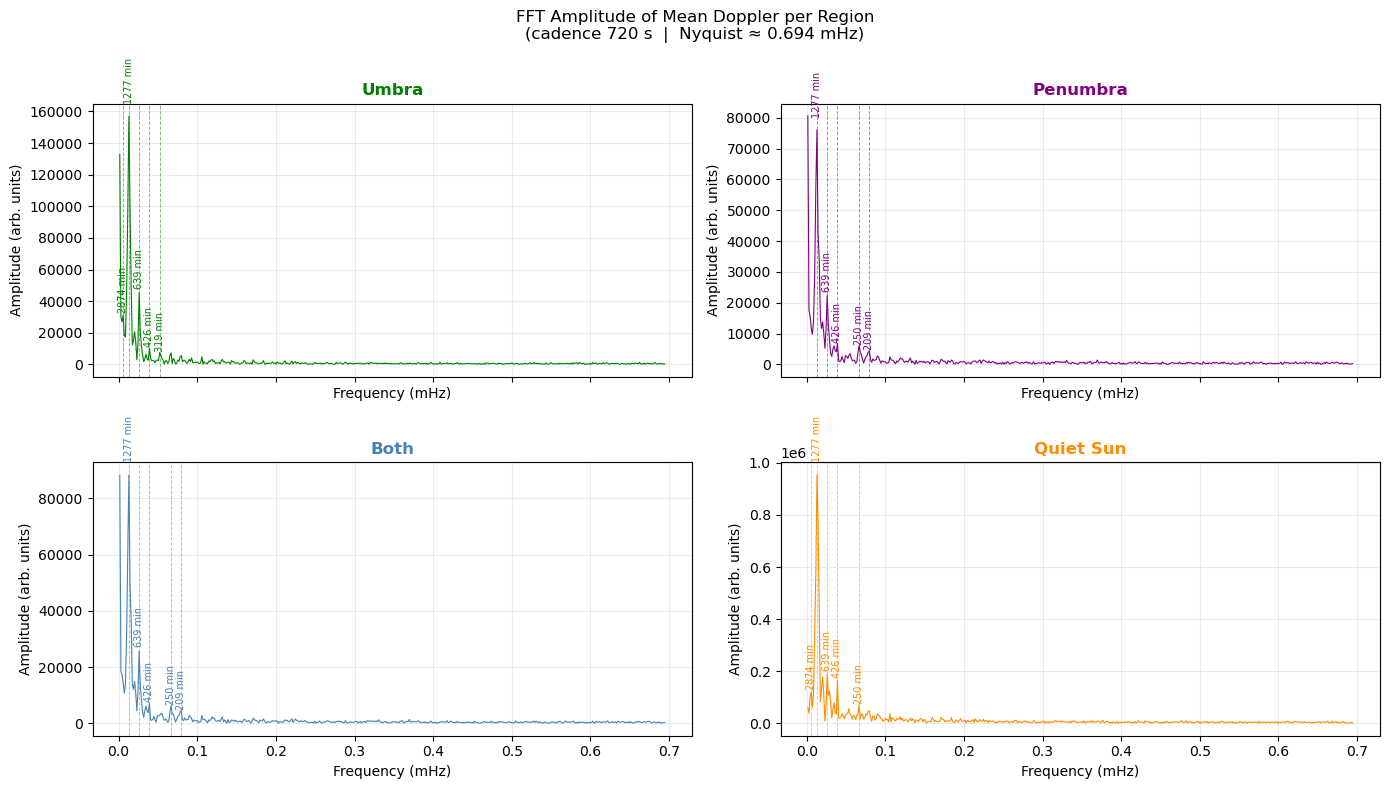


Region        Rank   Freq (mHz)   Period (min)  Rel. amplitude
────────────────────────────────────────────────────────────
Umbra            1       0.0130         1277.3          1.0000
Umbra            2       0.0261          638.7          0.2890
Umbra            3       0.0058         2874.0          0.1981
Umbra            4       0.0391          425.8          0.0658
Umbra            5       0.0522          319.3          0.0479

Penumbra         1       0.0130         1277.3          0.9440
Penumbra         2       0.0261          638.7          0.2786
Penumbra         3       0.0391          425.8          0.0841
Penumbra         4       0.0667          249.9          0.0764
Penumbra         5       0.0797          209.0          0.0538

Both             1       0.0130         1277.3          1.0000
Both             2       0.0261          638.7          0.2925
Both             3       0.0391          425.8          0.0826
Both             4       0.0667          249.9        

In [12]:
plot_ffts_separate(
    data, metrics,
    annotate_peaks = True,
    print_table    = True,
    save           = False,
    plots_dir      = plots_dir_06,
)

### 6b — Combined plot with x-axis zoom

Adjust `xlim` to focus on the frequency range of interest (in mHz).  
The peak-table CSV (`fft_peaks.csv`) is saved alongside the figure.

Figure saved → ../data/processed/sebastian_sun_spots/DS06/plots/fft_combined.png


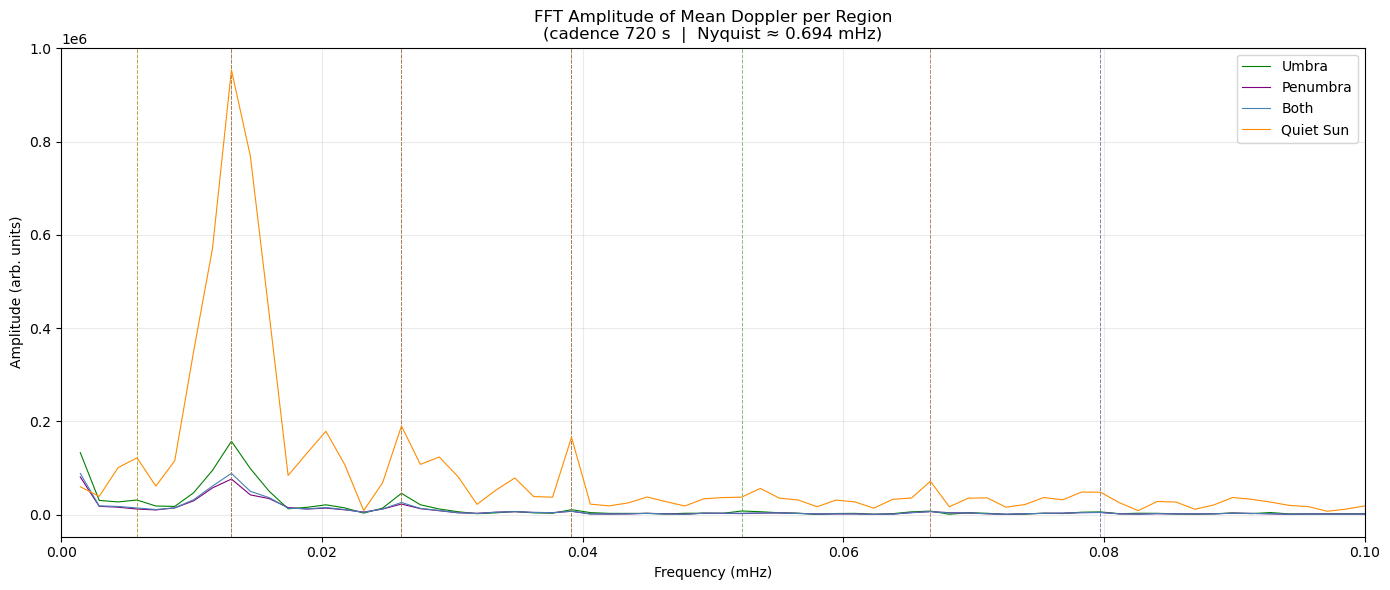


Region        Rank   Freq (mHz)   Period (min)  Rel. amplitude
────────────────────────────────────────────────────────────
Umbra            1       0.0130         1277.3          1.0000
Umbra            2       0.0261          638.7          0.2890
Umbra            3       0.0058         2874.0          0.1981
Umbra            4       0.0391          425.8          0.0658
Umbra            5       0.0522          319.3          0.0479

Penumbra         1       0.0130         1277.3          0.9440
Penumbra         2       0.0261          638.7          0.2786
Penumbra         3       0.0391          425.8          0.0841
Penumbra         4       0.0667          249.9          0.0764
Penumbra         5       0.0797          209.0          0.0538

Both             1       0.0130         1277.3          1.0000
Both             2       0.0261          638.7          0.2925
Both             3       0.0391          425.8          0.0826
Both             4       0.0667          249.9        

In [15]:
plot_ffts_combined(
    data, metrics,
    xlim           = (0, 0.1),   # mHz — change or set to None for full range
    annotate_peaks = True,
    print_table    = True,
    save           = True,
    plots_dir      = plots_dir_06,
)

## Step 7 — Save animation

In [16]:
anim_path = processed_dir_06 / 'anim.html'

save_animation(
    data, metrics,
    save_path = anim_path,
    step      = 50,   # include every 50th frame
    fps       = 5,
)

Animation saved → ../data/processed/sebastian_sun_spots/DS06/anim.html


In [17]:
# Open the saved animation in the browser
from IPython.display import FileLink
FileLink(str(anim_path))


/home/thomas/Desktop/sun_spots_pulsation_review/data/processed/sebastian_sun_spots/DS06/anim.html